In [24]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/alishermutalov/praktikum-datasets/refs/heads/praktikum/restaurant_sales.csv"
df = pd.read_csv(url)
df.head(15)

,Unnamed: 0,Order ID,Customer ID,Category,Item,Price,Quantity,Order Total,Order Date,Payment Method
0,0,ORD_705844,CUST_092,NaN,side salad#?,3.0,1.0,3.0,2023-12-21,Credit Card
1,1,ORD_338528,CUST_021,Side Dishes,Mashed Potatoes,4.0,3.0,12.0,2023-05-19,Digital Wallet
2,2,ORD_443849,CUST_029,Main Dishes,Grilled Chicken,15.0,4.0,60.0,2023-09-27,Credit Card
3,3,ORD_630508,CUST_075,Drinks,NaN,-1.0,2.0,5.0,2022-08-09,Credit Card
4,4,ORD_648269,CUST_031,Main Dishes,Pasta Alfredo,12.0,4.0,48.0,2022-05-15,Cash
5,5,ORD_381680,CUST_031,Main Dishes,Salmon,18.0,5.0,90.0,2022-07-20,Digital Wallet
6,6,ORD_270994,CUST_071,Side Dishes,Garlic Bread,4.0,5.0,20.0,2022-08-19,Credit Card
7,7,ORD_146656,CUST_077,Main Dishes,NaN,15.0,3.0,45.0,2023-02-15,Cash
8,8,ORD_428611,CUST_083,Desserts,NaN,6.0,2.0,12.0,2023-12-16,Cash
9,9,ORD_743636,CUST_085,Main Dishes,Vegetarian Platter,14.0,5.0,70.0,2022-08-07,NaN


In [2]:
df.columns

Index(['Unnamed: 0', 'Order ID', 'Customer ID', 'Category', 'Item', 'Price',
       'Quantity', 'Order Total', 'Order Date', 'Payment Method'],
      dtype='object')

In [27]:
df=df.drop(['Unnamed: 0'], axis=1)
# Because of we have another index column, We deleted Unnamed clumns as it used as a index

In [28]:
df

,Order ID,Customer ID,Category,Item,Price,Quantity,Order Total,Order Date,Payment Method
0,ORD_705844,CUST_092,NaN,side salad#?,3.0,1.0,3.0,2023-12-21,Credit Card
1,ORD_338528,CUST_021,Side Dishes,Mashed Potatoes,4.0,3.0,12.0,2023-05-19,Digital Wallet
2,ORD_443849,CUST_029,Main Dishes,Grilled Chicken,15.0,4.0,60.0,2023-09-27,Credit Card
3,ORD_630508,CUST_075,Drinks,NaN,-1.0,2.0,5.0,2022-08-09,Credit Card
4,ORD_648269,CUST_031,Main Dishes,Pasta Alfredo,12.0,4.0,48.0,2022-05-15,Cash
...,...,...,...,...,...,...,...,...,...
17529,ORD_320102,CUST_021,Drinks,NaN,-1.0,4.0,4.0,2023-12-23,Cash
17530,ORD_974128,CUST_069,Desserts,Ice Cream,5.0,3.0,15.0,2023-12-18,Cash
17531,ORD_108324,CUST_050,Desserts,Ice Cream,5.0,4.0,20.0,2022-05-20,Digital Wallet
17532,ORD_612647,CUST_073,Side Dishes,Mashed Potatoes,4.0,2.0,8.0,2022-01-27,Digital Wallet


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17534 entries, 0 to 17533
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        17534 non-null  object 
 1   Customer ID     17534 non-null  object 
 2   Category        17498 non-null  object 
 3   Item            15776 non-null  object 
 4   Price           17534 non-null  float64
 5   Quantity        17104 non-null  float64
 6   Order Total     17104 non-null  float64
 7   Order Date      17534 non-null  object 
 8   Payment Method  16452 non-null  object 
dtypes: float64(3), object(6)
memory usage: 1.2+ MB


In [5]:
df.describe()

,Price,Quantity,Order Total
count,17534.000000,17104.000000,17104.000000
mean,6.207312,3.014149,19.914494
std,4.993782,1.414598,18.732549
min,-1.000000,1.000000,1.000000
25%,3.000000,2.000000,7.500000
50%,5.000000,3.000000,15.000000
75%,7.000000,4.000000,25.000000
max,20.000000,5.000000,100.000000


In [35]:
df.isnull().sum()

,0
Order ID,0
Customer ID,0
Category,0
Item,1758
Price,0
Quantity,430
Order Total,430
Order Date,0
Payment Method,1082


In [44]:
df[["Category", 'Item', 'Quantity', 'Order Total', 'Payment Method' ]]

,Category,Item,Quantity,Order Total,Payment Method
0,Main Dishes,side salad#?,1.0,3.0,Credit Card
1,Side Dishes,Mashed Potatoes,3.0,12.0,Digital Wallet
2,Main Dishes,Grilled Chicken,4.0,60.0,Credit Card
3,Drinks,Pasta Alfredo,2.0,5.0,Credit Card
4,Main Dishes,Pasta Alfredo,4.0,48.0,Cash
...,...,...,...,...,...
17529,Drinks,Pasta Alfredo,4.0,4.0,Cash
17530,Desserts,Ice Cream,3.0,15.0,Cash
17531,Desserts,Ice Cream,4.0,20.0,Digital Wallet
17532,Side Dishes,Mashed Potatoes,2.0,8.0,Digital Wallet


In [51]:

df.Category.value_counts()
#  We fill Category columns by using of mode method.
df['Category'].fillna(df['Category'].mode()[0], inplace=True)

/tmp/ipykernel_6148/4040835026.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Category'].fillna(df['Category'].mode()[0], inplace=True)


In [ ]:
df['Item'].value_counts()
df['Item'].fillna(df['Item'].mode()[0], inplace=True)

In [45]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [41]:
df['Quantity'].value_counts()
df['Quantity'].fillna(df['Quantity'].median(), inplace=True)

/tmp/ipykernel_6148/995276867.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Quantity'].fillna(df['Quantity'].median(), inplace=True)


In [46]:
df['Order_Total'].value_counts()
df['Order_Total'] = df['Price'] * df['Quantity']

In [48]:
df['Payment_Method'].value_counts()
df['Payment_Method'].ffill(inplace=True)

In [49]:
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Category,0
Item,0
Price,0
Quantity,0
Order_Total,0
Order_Date,0
Payment_Method,0


In [53]:
(df[['Price', 'Quantity', 'Order_Total' ]]<0).sum()
#We check the numerical columns to identify whether they contain any negative values.
# If negative values are present, we convert them to their absolute (positive) form using the `abs()` function.

,0
Price,876
Quantity,0
Order_Total,876


In [54]:
df[['Price', 'Order_Total' ]]=df[['Price', 'Order_Total' ]].abs()

In [55]:
(df[['Price', 'Quantity', 'Order_Total' ]]<0).sum()

,0
Price,0
Quantity,0
Order_Total,0


In [ ]:
#We examine the string (categorical) columns to identify whether they contain any inconsistencies or typos.
This includes differences in capitalization, extra spaces, or special characters that may represent the same value in different forms.

In [56]:
df[ df[['Category', 'Item', 'Payment_Method']]
    .apply(lambda x: x.str.contains(r'[^a-zA-Z0-9\s]', na=False))
    .any(axis=1)]

,Order_ID,Customer_ID,Category,Item,Price,Quantity,Order_Total,Order_Date,Payment_Method
0,ORD_705844,CUST_092,Main Dishes,side salad#?,3.0,1.0,3.0,2023-12-21,Credit Card
73,ORD_771998,CUST_070,Drinks,Water (0.5),1.0,4.0,4.0,2022-01-11,Cash
85,ORD_539782,CUST_060,Side Dishes,Grilled Vegetables?,5.0,1.0,5.0,2022-03-28,Credit Card
100,ORD_696255,CUST_055,Starters,NACHOS GRANDE#,10.0,1.0,10.0,2022-07-29,Digital Wallet
101,ORD_749532,CUST_063,Drinks,Water (0.5),1.0,5.0,5.0,2023-02-26,Credit Card
...,...,...,...,...,...,...,...,...,...
17486,ORD_866026,CUST_071,Drinks,Water (0.5),1.0,2.0,2.0,2023-07-29,Cash
17500,ORD_230561,CUST_085,Main Dishes,BEEF CHILI#,7.0,3.0,21.0,2023-03-27,Cash
17502,ORD_429628,CUST_063,Drinks,Water (0.5),1.0,3.0,3.0,2022-05-25,Digital Wallet
17507,ORD_485156,CUST_090,Drinks,Water (0.5),1.0,1.0,1.0,2022-03-24,Digital Wallet


In [57]:
df['Item'].unique()


array(['side salad#?', 'Mashed Potatoes', 'Grilled Chicken',
       'Pasta Alfredo', 'Salmon', 'Garlic Bread', 'Vegetarian Platter',
       'Brownie', 'Sweet Potato Fries', 'Lemonade', 'Side Salad',
       'Orange Juice', 'Chocolate Cake', 'COCA COLA',
       'Grilled Vegetables', 'Coca Cola', 'Cheese Fries', 'Beef Chili',
       'Chicken Melt', 'Fruit Salad', 'French Fries', 'Ice Cream',
       'Cheesecake', 'CHOCOLATE CAKE', 'grilled vegetables', 'Iced Tea',
       'Water (0.5)', 'Grilled Vegetables?', 'NACHOS GRANDE#', 'water',
       'Onion Rings', 'STEAK', 'Steak', 'LEMONADE', 'Nachos Grande',
       'Grilled Chicken?', 'ICED TEA', 'CHICKEN MELT#', 'lemonade (1.0)',
       'ICE CREAM', 'GRILLED CHICKEN', 'french fries', 'GRILLED CHICKEN#',
       'grilled chicken', 'Coca Cola?', 'FRUIT SALAD', 'steak', 'STEAK#',
       'COCA COLA?', 'fruit salad', 'MASHED POTATOES', 'cheesecake',
       'ORANGE JUICE#', 'French Fries?', 'CHEESE FRIES', 'Side Salad?',
       'FRENCH FRIES#', 'SWEET

In [58]:
df['Item'] = (
    df['Item']
    .str.lower()
    .str.replace(r'[^a-z\s]', '', regex=True)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()
)

In [59]:
df['Item'].unique()


array(['Side Salad', 'Mashed Potatoes', 'Grilled Chicken',
       'Pasta Alfredo', 'Salmon', 'Garlic Bread', 'Vegetarian Platter',
       'Brownie', 'Sweet Potato Fries', 'Lemonade', 'Orange Juice',
       'Chocolate Cake', 'Coca Cola', 'Grilled Vegetables',
       'Cheese Fries', 'Beef Chili', 'Chicken Melt', 'Fruit Salad',
       'French Fries', 'Ice Cream', 'Cheesecake', 'Iced Tea', 'Water',
       'Nachos Grande', 'Onion Rings', 'Steak'], dtype=object)

In [60]:
df[['Category', 'Item', 'Payment_Method']].dtypes

,0
Category,object
Item,object
Payment_Method,object


In [61]:
df[['Category', 'Item', 'Payment_Method']]=df[['Category', 'Item', 'Payment_Method']].astype('string')

In [62]:
from datetime import datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [63]:
df.dtypes

,0
Order_ID,object
Customer_ID,object
Category,string[python]
Item,string[python]
Price,float64
Quantity,float64
Order_Total,float64
Order_Date,datetime64[ns]
Payment_Method,string[python]


In [ ]:
## Checking Duplicates in Identifier Columns
In this step, we analyze the uniqueness and duplication of key identifier columns such as `Customer_ID` and `Order_ID`.

- Duplicate values are **expected and valid**
- Helps to understand customer behavior and frequency of purchases


In [ ]:
# The `Customer_ID` represents individual customers.
It is expected that a single customer can place multiple orders.

In [65]:
df['Customer_ID'].value_counts()

,count
Customer_ID,
CUST_066,207
CUST_100,200
CUST_055,199
CUST_087,199
CUST_028,198
...,...
CUST_030,153
CUST_045,152
CUST_095,150


In [ ]:
# The Order_ID represents a unique transaction.

Duplicate values are NOT expected
Each order should have a unique identifier
Duplicates may indicate data quality issues

In [66]:
df['Order_ID'].value_counts()

,count
Order_ID,
ORD_680707,1
ORD_705844,1
ORD_338528,1
ORD_443849,1
ORD_630508,1
...,...
ORD_337802,1
ORD_283207,1
ORD_736695,1


In [67]:
top_items = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False).head(5)
print(top_items)

Item
Pasta Alfredo    8364.0
Side Salad       2932.0
Ice Cream        2929.0
Water            2899.0
French Fries     2721.0
Name: Quantity, dtype: float64


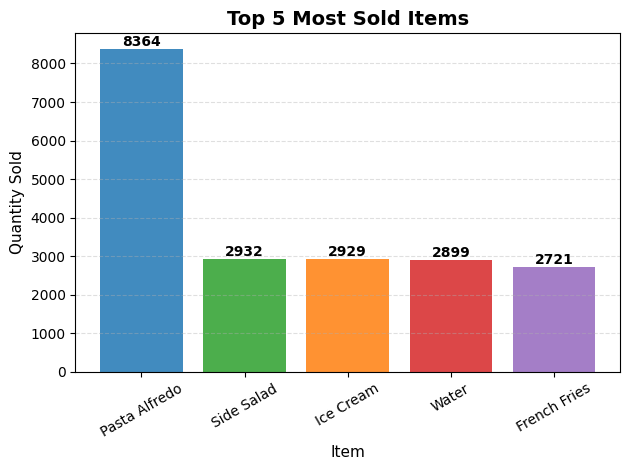

In [68]:
import matplotlib.pyplot as plt

top_items = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False).head(5)

plt.figure()

colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd']

bars = plt.bar(top_items.index, top_items.values, color=colors, alpha=0.85)


for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, int(y),
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Top 5 Most Sold Items", fontsize=14, fontweight='bold')
plt.xlabel("Item", fontsize=11)
plt.ylabel("Quantity Sold", fontsize=11)

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
avg_spent = df.groupby('Customer_ID')['Order_Total'].mean()
print(avg_spent)

Customer_ID
CUST_001    17.445402
CUST_002    19.037791
CUST_003    16.713376
CUST_004    19.201807
CUST_005    17.839869
              ...    
CUST_096    18.460938
CUST_097    19.632597
CUST_098    19.279661
CUST_099    20.465190
CUST_100    18.420918
Name: Order_Total, Length: 100, dtype: float64


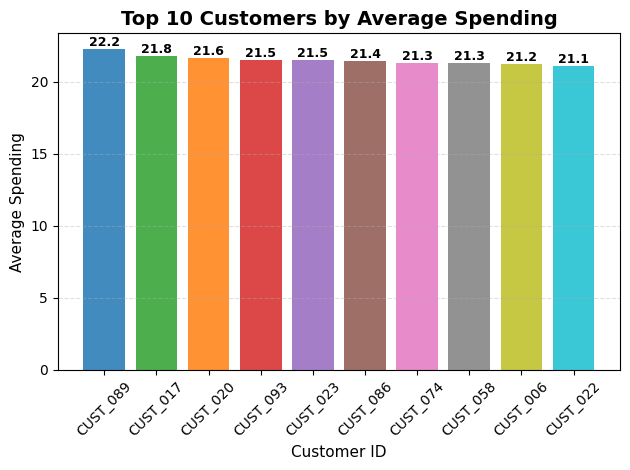

In [69]:
import matplotlib.pyplot as plt

avg_spent = df.groupby('Customer_ID')['Order_Total'].mean().sort_values(ascending=False).head(10)
plt.figure()
colors = ['#1f77b4','#2ca02c','#ff7f0e','#d62728','#9467bd',
          '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']

bars = plt.bar(avg_spent.index.astype(str), avg_spent.values, color=colors, alpha=0.85)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"{y:.1f}",
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title("Top 10 Customers by Average Spending", fontsize=14, fontweight='bold')
plt.xlabel("Customer ID", fontsize=11)
plt.ylabel("Average Spending", fontsize=11)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [70]:
df['Day'] = df['Order_Date'].dt.day_name()

sales_by_day = df.groupby('Day')['Order_Total'].sum().sort_values(ascending=False)
print(sales_by_day)

Day
Sunday       49029.5
Tuesday      48471.5
Monday       48294.5
Friday       47486.0
Saturday     47406.5
Thursday     47386.0
Wednesday    46366.0
Name: Order_Total, dtype: float64


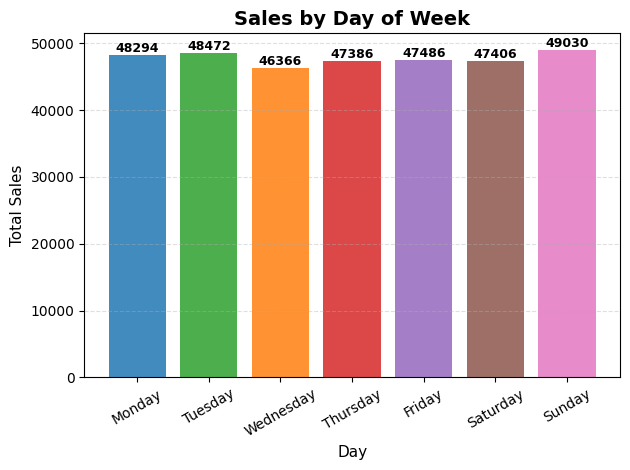

In [71]:
import matplotlib.pyplot as plt

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

df['Day'] = df['Order_Date'].dt.day_name()
sales_by_day = df.groupby('Day')['Order_Total'].sum().reindex(day_order)

plt.figure()
colors = ['#1f77b4','#2ca02c','#ff7f0e','#d62728','#9467bd','#8c564b','#e377c2']

bars = plt.bar(sales_by_day.index, sales_by_day.values, color=colors, alpha=0.85)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"{y:.0f}",
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title("Sales by Day of Week", fontsize=14, fontweight='bold')
plt.xlabel("Day", fontsize=11)
plt.ylabel("Total Sales", fontsize=11)

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
#we identify products whose prices are significantly higher than the average price.

In [73]:
avg_price = df['Price'].mean()

expensive_items = df[df['Price'] > 2 * avg_price]
print(expensive_items[['Item','Price']])

                     Item  Price
2         Grilled Chicken   15.0
5                  Salmon   18.0
7           Pasta Alfredo   15.0
9      Vegetarian Platter   14.0
11                 Salmon   18.0
...                   ...    ...
17453              Salmon   18.0
17480              Salmon   18.0
17490              Salmon   18.0
17495               Steak   20.0
17505       Pasta Alfredo   15.0

[2311 rows x 2 columns]


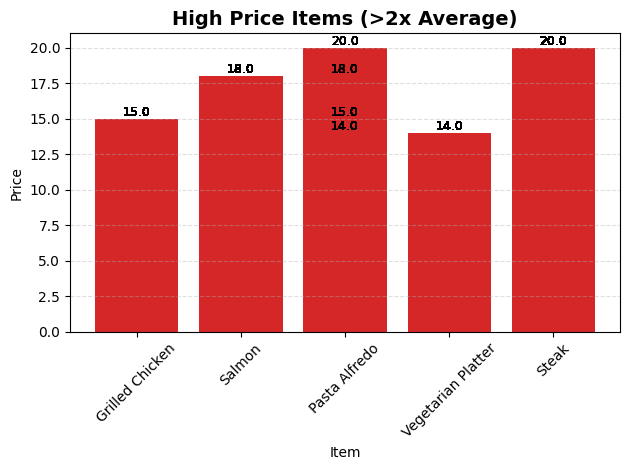

In [74]:
colors = ['#d62728'] * len(expensive_items)

plt.figure()
bars = plt.bar(expensive_items['Item'], expensive_items['Price'], color=colors, alpha=0.8)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"{y:.1f}",
             ha='center', va='bottom', fontsize=9)

plt.title("High Price Items (>2x Average)", fontsize=14, fontweight='bold')
plt.xlabel("Item")
plt.ylabel("Price")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [75]:
category_sales = df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)
print(category_sales)

Category
Main Dishes    10906.0
Starters       10560.0
Desserts       10513.0
Drinks         10496.0
Side Dishes    10369.0
Name: Quantity, dtype: float64


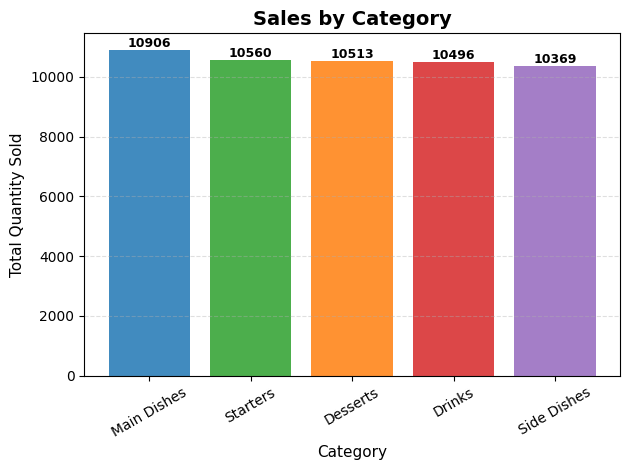

In [76]:
import matplotlib.pyplot as plt

category_sales = df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)

plt.figure()

colors = ['#1f77b4','#2ca02c','#ff7f0e','#d62728','#9467bd',
          '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']

bars = plt.bar(category_sales.index, category_sales.values, color=colors[:len(category_sales)], alpha=0.85)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, int(y),
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title("Sales by Category", fontsize=14, fontweight='bold')
plt.xlabel("Category", fontsize=11)
plt.ylabel("Total Quantity Sold", fontsize=11)

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [77]:
avg_quantity = df.groupby('Customer_ID')['Quantity'].mean()
print(avg_quantity)

Customer_ID
CUST_001    2.955056
CUST_002    3.112994
CUST_003    2.944785
CUST_004    3.080460
CUST_005    2.930380
              ...   
CUST_096    2.974227
CUST_097    3.043478
CUST_098    3.083333
CUST_099    2.963190
CUST_100    2.975000
Name: Quantity, Length: 100, dtype: float64


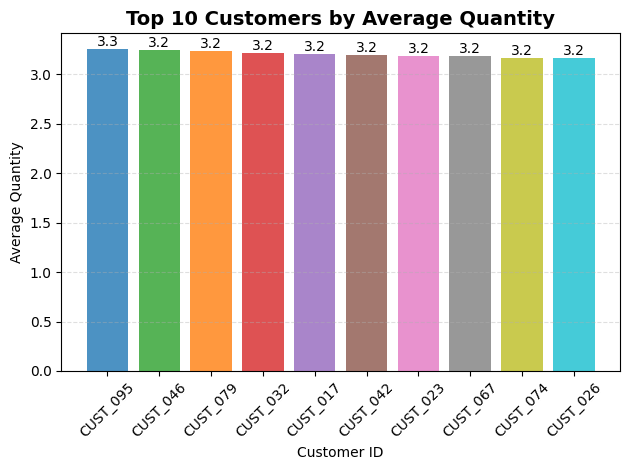

In [78]:
import matplotlib.pyplot as plt

avg_quantity = df.groupby('Customer_ID')['Quantity'].mean().sort_values(ascending=False).head(10)

plt.figure()

bars = plt.bar(avg_quantity.index.astype(str), avg_quantity.values,
           color= ['#1f77b4','#2ca02c','#ff7f0e','#d62728','#9467bd',
          '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf'],
           alpha=0.8)

# qiymat yozish
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"{y:.1f}",
             ha='center', va='bottom')

plt.title("Top 10 Customers by Average Quantity", fontsize=14, fontweight='bold')
plt.xlabel("Customer ID")
plt.ylabel("Average Quantity")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()